# Per-mirror piston/tip/tilt fit of a segment tilt event

In July 2022 several JWST primary-mirror segments moved between two wavefront-sensing epochs. This example fits the epoch after the event in `ptt_pixel` mode: the OPD is a piston, tip and tilt plane on each of the 18 physical mirror segments, plus a pixel-level residual kept orthogonal to those planes.

Large tilts are hard to fit from zero, so we use the epoch before the event:

1. Fit the previous epoch in pixel mode, from zero.
2. Fit the event epoch in `ptt_pixel` mode, starting from the previous epoch and re-searching a grid of piston/tip/tilt seeds on every mirror.
3. Compare the two epochs to see which mirrors moved.

In [1]:
%matplotlib inline

from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt

from camino.data_utils import download_wlp8_wlm8, previous_wfs_epoch
from camino.fitting import (
    FitConfig,
    diagnose_mirror_changes,
    fit_data,
    get_mast_wss_path,
    load_data,
)

Download the event epoch and set it up as a `ptt_pixel` problem, with 256×256 cutouts.

In [2]:
OBS_DATE = "2022-07-13"
OUTPUT_DIR = Path(f"{OBS_DATE.replace('-', '')}_pttpixel")

event_paths = download_wlp8_wlm8(OBS_DATE, download_dir=OUTPUT_DIR / "data")

config = FitConfig.for_mode("ptt_pixel", stage2_maxiter=5000, show_plots=False)
data = load_data(*event_paths, config=config)

Date     : 2022-07-13
OPD      : R2022071306
Detector : NRCA3
WLM8     : jw02726027001_03104_00001 | 2022-07-12T15:55:15.0240000
WLP8     : jw02726027001_03105_00001 | 2022-07-12T16:02:24.5280000
Already exists: jw02726027001_03104_00001_nrca3_cal.fits
Already exists: jw02726027001_03105_00001_nrca3_cal.fits


## 1. The previous epoch

`previous_wfs_epoch` finds the last wavefront-sensing epoch before these exposures that has a WLP8/WLM8 pair. We fit it in pixel mode with the same 256-pixel window. With no tilt event, this converges quickly from zero.

In [3]:
PREVIOUS_EPOCH = previous_wfs_epoch(data.observation_time - timedelta(minutes=1))
previous_paths = download_wlp8_wlm8(PREVIOUS_EPOCH, download_dir=Path(f"{PREVIOUS_EPOCH:%Y%m%d}_pixel") / "data")

pixel_config = FitConfig.for_mode("pixel", fit_npix=256, show_plots=False)
previous = fit_data(data=load_data(*previous_paths, config=pixel_config))

Previous epoch: 2022-07-10 11:35 UTC (O2022071001)
Date     : 2022-07-10
OPD      : O2022071001
Detector : NRCA3
WLM8     : jw02725187001_03104_00001 | 2022-07-10T11:35:37.8080000
WLP8     : jw02725187001_03105_00001 | 2022-07-10T11:42:58
Already exists: jw02725187001_03104_00001_nrca3_cal.fits
Already exists: jw02725187001_03105_00001_nrca3_cal.fits
CAMINO pixel: 256x256 cutouts; zero initial OPD


Stage 2 — L-BFGS-B: 100%|██████████| 69/69 [00:31<00:00,  2.21iter/s, grad=5.548e-03, loss=9.483134e+05]


Stage 2 — L-BFGS-B: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH; iterations=69, loss=9.48313359e+05


## 2. PTT fit of the event epoch

Start from the previous epoch's solution, split into per-mirror piston/tip/tilt and an orthogonal residual. The fit refits the image positions and defocus, then re-searches a grid of 27 piston/tip/tilt seeds on each mirror (also seeded from its previous value), propagating only that mirror's segment over a cached field of the others. It then fits all 54 PTT coefficients jointly, and finishes with a joint fit of the coefficients and the pixel residual.

CAMINO ptt_pixel: 256x256 cutouts; warm start from previous fit (pixel fit)


Stage 0 — BFGS positions: 100%|██████████| 31/31 [00:25<00:00,  1.23iter/s, grad=1.554e-03, loss=2.042584e+07]


Stage 0 — BFGS positions: Optimization terminated successfully.; iterations=31, loss=2.04258394e+07


Stage 1a — local PTT physical 1: 100%|██████████| 5/5 [00:00<00:00,  7.59iter/s, grad=1.715e-02, loss=2.040906e+07]


Stage 1a — local PTT physical 1: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH; iterations=5, loss=2.04090611e+07


...

Stage 1 — joint PTT BFGS: Optimization terminated successfully.; iterations=69, loss=2.26423086e+06


Stage 1b — BFGS position refit: 100%|██████████| 35/35 [00:23<00:00,  1.48iter/s, grad=1.493e-03, loss=9.992709e+05]


Stage 1b — BFGS position refit: Optimization terminated successfully.; iterations=35, loss=9.99270859e+05


Stage 2 — L-BFGS-B: 100%|██████████| 62/62 [00:35<00:00,  1.75iter/s, grad=2.104e-02, loss=9.620979e+05]


Stage 2 — L-BFGS-B: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH; iterations=62, loss=9.62097875e+05
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


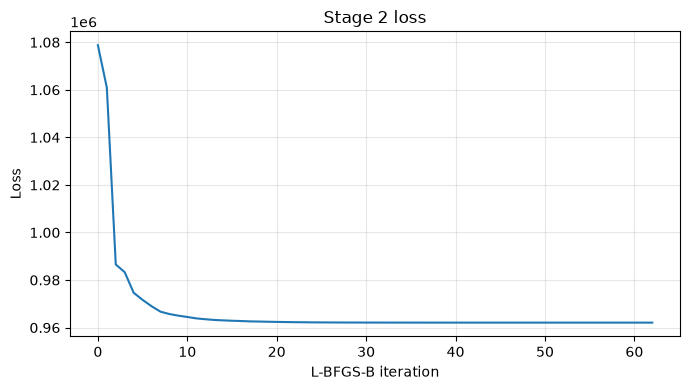

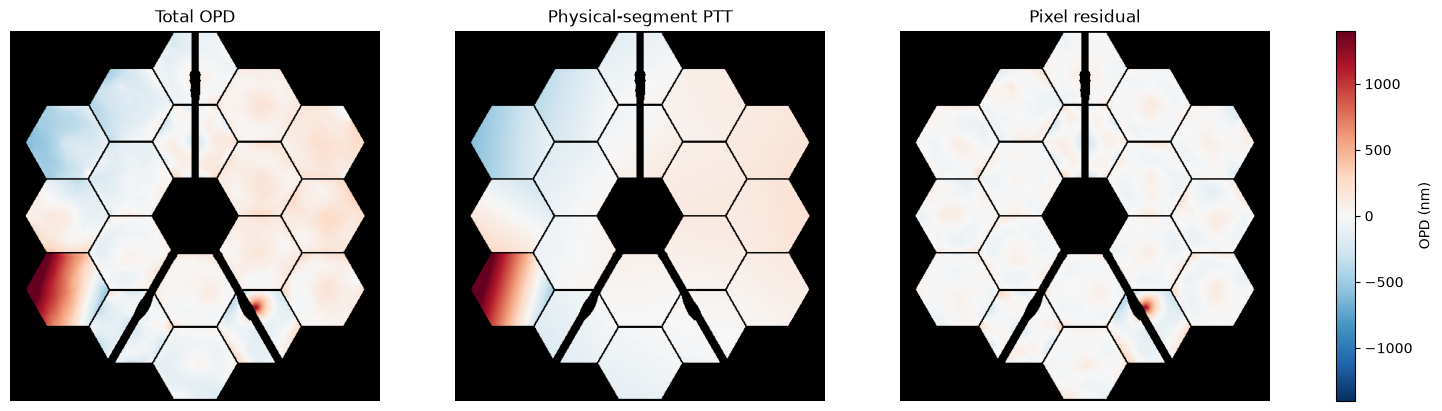

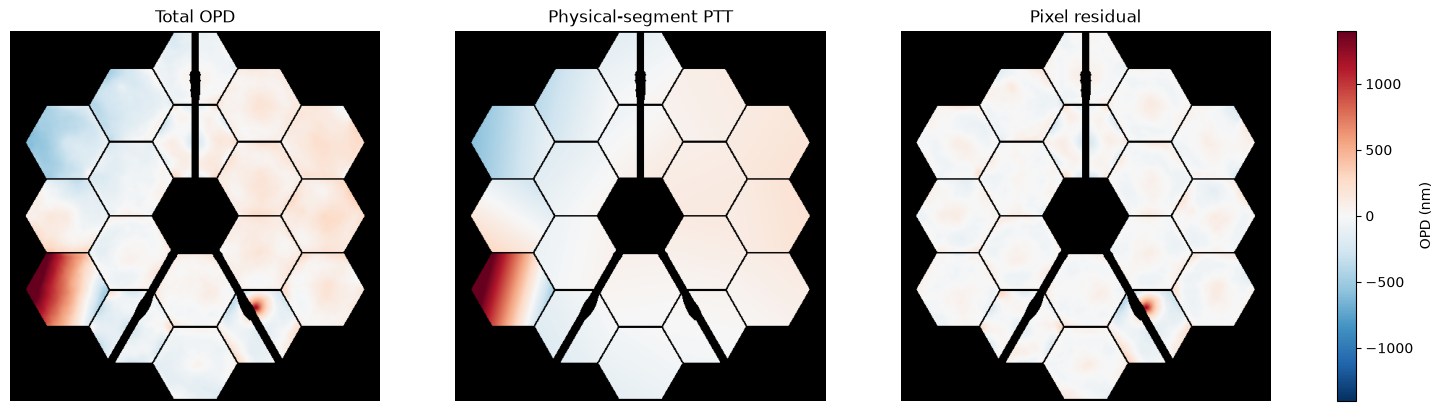

In [4]:
result = fit_data(data=data, initial=previous, reseed="all", output_dir=OUTPUT_DIR)
print(result.scipy_result.message)

result.plot_loss()
result.plot_opd()

## 3. Which mirrors moved?

`diagnose_mirror_changes` projects each mirror's OPD change between the two epochs onto its piston/tip/tilt, removes the change common to all mirrors (it trades against the image position), and flags mirrors whose tip/tilt changed by much more than the rest.

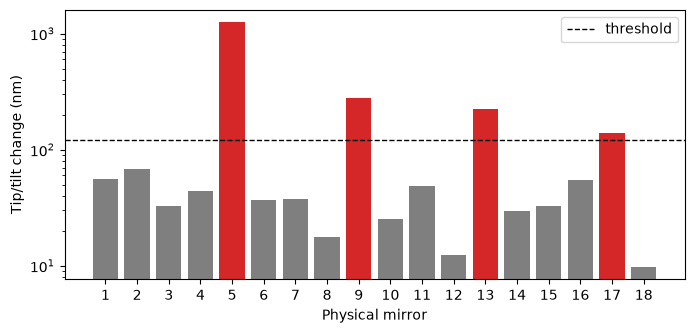

Mirrors that moved: (5, 9, 13, 17)


In [5]:
diagnosis = diagnose_mirror_changes(data, result, previous)

rows = diagnosis["table"]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(
    [r["mirror"] for r in rows],
    [r["tip_tilt_change_nm"] for r in rows],
    color=["tab:red" if r["flagged"] else "tab:gray" for r in rows],
)
ax.axhline(diagnosis["threshold_nm"], color="k", ls="--", lw=1, label="threshold")
ax.set(xlabel="Physical mirror", ylabel="Tip/tilt change (nm)", yscale="log", xticks=range(1, 19))
ax.legend()
plt.show()

print("Mirrors that moved:", diagnosis["flagged"])

Finally, compare with the official wavefront-sensing solution from MAST:

MAST WSS: R2022071306-NRCA3_FP1-1.fits
WLP8: CAMINO mean(z²)=7.561; MAST mean(z²)=76.064
WLM8: CAMINO mean(z²)=7.271; MAST mean(z²)=19.640


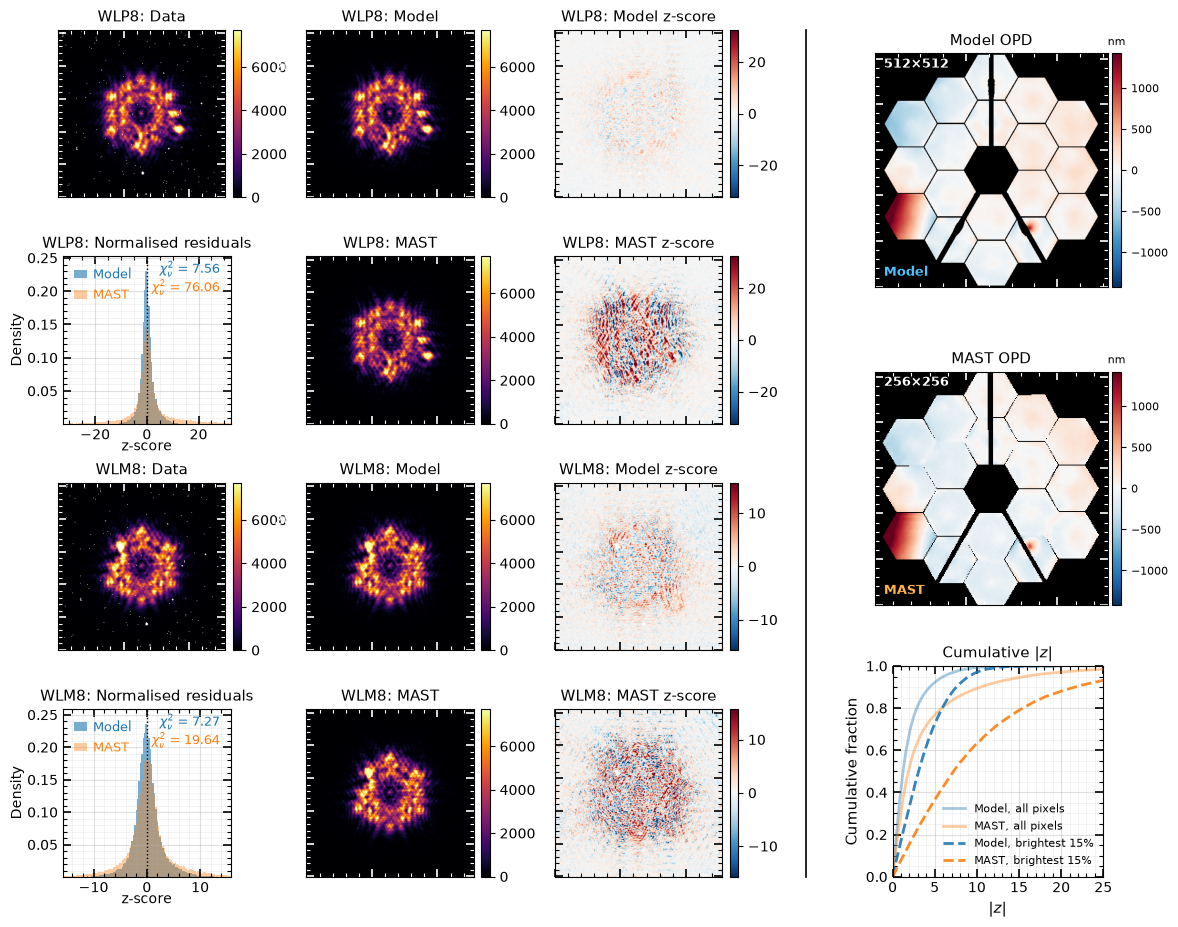

In [6]:
MAST_WSS_PATH = get_mast_wss_path(f"{OBS_DATE}T12:00:00", choice="closest")

print("MAST WSS:", MAST_WSS_PATH.name)

comparison = result.compare_with_mast(
    MAST_WSS_PATH,
    calc_hdu={"WLM8": 6, "WLP8": 11},
)